In [27]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
import operator

In [28]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation: str
    disc: float
    result:str


In [29]:
def create_eq(state: QuadState):
    equation=f'{state["a"]}x2+({state["b"]}x)+({state["c"]})'
    return {'equation':equation}

def disc_calculator(state: QuadState):
    disc= state["b"]**2-(4*state["a"]*state["c"])
    state["disc"]=disc
    return {'disc':disc}


In [30]:
def rl_roots(state: QuadState):
    root1=(-state['b']+state['disc']**0.5/(2*state['a']))
    root2=(-state['b']-state['disc']**0.5/(2*state['a']))
    result=f'the roots are {root1} and {root2}'
    return {'result':result}
def equal_roots(state: QuadState):
    root=(-state['b']/(2*state['a']))
    result=f'the root repeating is {root}'
    return {'result':result}
def img_roots(state: QuadState):
    result=f'no real roots'
    return {'result':result}



In [31]:
def check_condition(state: QuadState)-> Literal["rl_roots","equal_roots","img_roots"]:
    if state["disc"]>0:
        return "rl_roots"
    elif state["disc"]==0:
        return "equal_roots"
    else:
        return "img_roots"


In [32]:
graph=StateGraph(QuadState)
graph.add_node('show_equation',create_eq)
graph.add_node('get_disc',disc_calculator)
graph.add_node('rl_roots',rl_roots)
graph.add_node('img_roots',img_roots)
graph.add_node('equal_roots',equal_roots)

graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','get_disc')
graph.add_conditional_edges('get_disc',check_condition)
graph.add_edge('rl_roots',END)
graph.add_edge('img_roots',END)
graph.add_edge('equal_roots',END)
workflow=graph.compile()





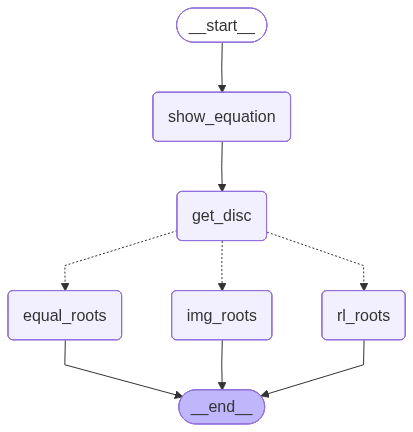

In [33]:
workflow

In [ ]:
inital_state={
    'a':1,
    'b':-5,
    'c':5
}
final_state=workflow.invoke(inital_state)
print(final_state)

{'a': 1, 'b': -5, 'c': 5, 'equation': '1x2+(-5x)+(5)', 'disc': 5, 'result': 'the roots are 6.118033988749895 and 3.881966011250105'}


: 